In [1]:
import evidently
print(f'Evidently version : {evidently.__version__}')

Evidently version : 0.7.21


RAPPORT DATA DRIFT — Test de Kolmogorov-Smirnov
Feature                           p-value                Drift
----------------------------------------------------------------------
AMT_INCOME_TOTAL                   0.0000     DRIFT DETECTE ⚠️
AMT_CREDIT                         0.0000     DRIFT DETECTE ⚠️
AMT_ANNUITY                        1.0000             Stable ✅
AGE_YEARS                          0.0000     DRIFT DETECTE ⚠️
EXT_SOURCE_MEAN                    0.0000     DRIFT DETECTE ⚠️
CREDIT_INCOME_RATIO                1.0000             Stable ✅
ANNUITY_INCOME_RATIO               1.0000             Stable ✅
YEARS_EMPLOYED                     1.0000             Stable ✅

Bilan : 4/8 features avec drift détecté


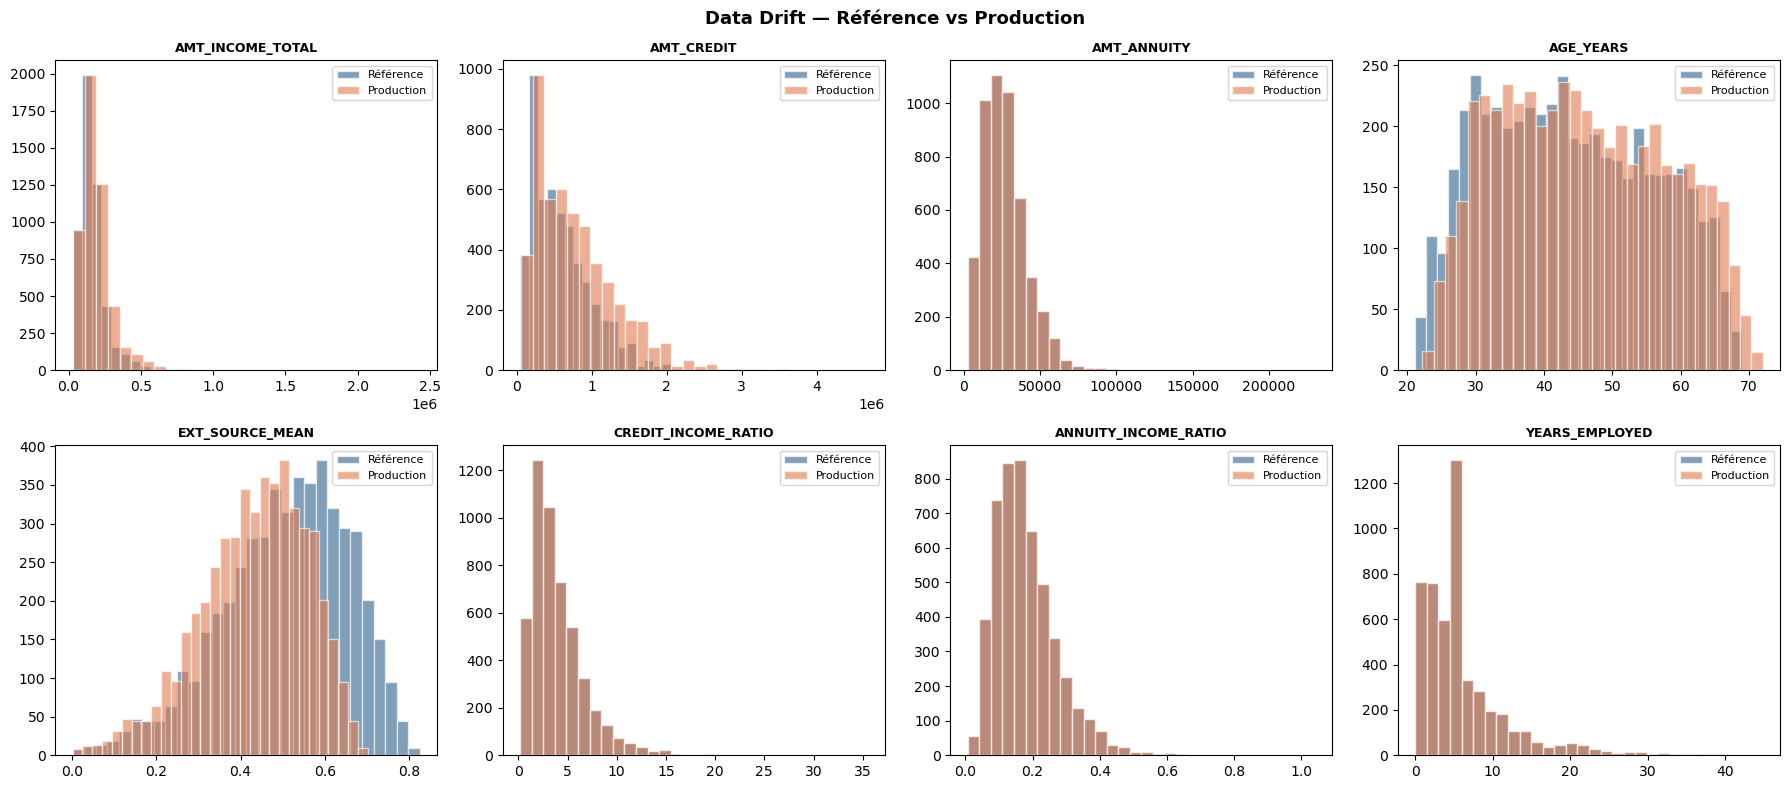


✅ Graphique sauvegardé : C:\Users\Frank\Desktop\home-credit-MLOPS\data\processed\fig_data_drift.png

STRATÉGIE DE RÉENTRAÎNEMENT

1. MONITORING CONTINU
   → Calculer le test KS chaque semaine sur les nouvelles données
   → Seuil d alerte : p-value < 0.05 sur plus de 3 features

2. DÉCLENCHEMENT DU RÉENTRAÎNEMENT
   → Si drift détecté sur EXT_SOURCE_MEAN ou AMT_CREDIT → réentraîner immédiatement
   → Si drift détecté sur features secondaires → alerte + surveillance renforcée

3. PROCESSUS DE RÉENTRAÎNEMENT
   → Collecter 3 mois de nouvelles données
   → Réentraîner XGBoost avec les mêmes hyperparamètres
   → Comparer AUC-ROC nouveau vs ancien modèle
   → Déployer si AUC-ROC nouveau >= AUC-ROC ancien - 0.01

4. FRÉQUENCE
   → Vérification hebdomadaire automatique via GitHub Actions
   → Réentraînement trimestriel même sans drift détecté

✅ Analyse Data Drift complète


In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import os

# Charger les données
df = pd.read_csv(r'C:\Users\Frank\Desktop\home-credit-MLOPS\data\processed\application_train_clean.csv')

cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
        'AGE_YEARS', 'EXT_SOURCE_MEAN', 'CREDIT_INCOME_RATIO',
        'ANNUITY_INCOME_RATIO', 'YEARS_EMPLOYED']
cols = [c for c in cols if c in df.columns]

reference   = df[cols].sample(5000, random_state=42)

# Simuler données de production avec drift
np.random.seed(123)
production  = reference.copy()
production['AMT_INCOME_TOTAL'] *= 1.20
production['AMT_CREDIT']       *= 1.30
production['AGE_YEARS']        += np.random.normal(2, 1, len(production))
production['EXT_SOURCE_MEAN']  *= 0.85

# Analyse du drift avec test de Kolmogorov-Smirnov
print('=' * 70)
print('RAPPORT DATA DRIFT — Test de Kolmogorov-Smirnov')
print('=' * 70)
print(f'{"Feature":<30} {"p-value":>10} {"Drift":>20}')
print('-' * 70)

resultats_drift = []
for col in cols:
    ks_stat, p_value = stats.ks_2samp(reference[col].dropna(), production[col].dropna())
    drift = 'DRIFT DETECTE ⚠️' if p_value < 0.05 else 'Stable ✅'
    ref_mean  = reference[col].mean()
    prod_mean = production[col].mean()
    diff_pct  = abs(prod_mean - ref_mean) / abs(ref_mean) * 100
    print(f'{col:<30} {p_value:>10.4f} {drift:>20}')
    resultats_drift.append({
        'feature'  : col,
        'p_value'  : round(p_value, 4),
        'drift'    : drift,
        'ref_mean' : round(ref_mean, 2),
        'prod_mean': round(prod_mean, 2),
        'diff_pct' : round(diff_pct, 1)
    })

print('=' * 70)
n_drift = sum(1 for r in resultats_drift if 'DRIFT' in r['drift'])
print(f'\nBilan : {n_drift}/{len(cols)} features avec drift détecté')

# Visualisation
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(reference[col], bins=30, alpha=0.6, color='#2C5F8A', label='Référence', edgecolor='white')
    axes[i].hist(production[col], bins=30, alpha=0.6, color='#E07B4F', label='Production', edgecolor='white')
    axes[i].set_title(col, fontweight='bold', fontsize=9)
    axes[i].legend(fontsize=8)

plt.suptitle('Data Drift — Référence vs Production', fontsize=13, fontweight='bold')
plt.tight_layout()

output_fig = r'C:\Users\Frank\Desktop\home-credit-MLOPS\data\processed\fig_data_drift.png'
plt.savefig(output_fig, bbox_inches='tight', dpi=150)
plt.show()
print(f'\n✅ Graphique sauvegardé : {output_fig}')

# Stratégie de réentraînement
print('\n' + '=' * 70)
print('STRATÉGIE DE RÉENTRAÎNEMENT')
print('=' * 70)
print("""
1. MONITORING CONTINU
   → Calculer le test KS chaque semaine sur les nouvelles données
   → Seuil d alerte : p-value < 0.05 sur plus de 3 features

2. DÉCLENCHEMENT DU RÉENTRAÎNEMENT
   → Si drift détecté sur EXT_SOURCE_MEAN ou AMT_CREDIT → réentraîner immédiatement
   → Si drift détecté sur features secondaires → alerte + surveillance renforcée

3. PROCESSUS DE RÉENTRAÎNEMENT
   → Collecter 3 mois de nouvelles données
   → Réentraîner XGBoost avec les mêmes hyperparamètres
   → Comparer AUC-ROC nouveau vs ancien modèle
   → Déployer si AUC-ROC nouveau >= AUC-ROC ancien - 0.01

4. FRÉQUENCE
   → Vérification hebdomadaire automatique via GitHub Actions
   → Réentraînement trimestriel même sans drift détecté
""")
print('✅ Analyse Data Drift complète')

In [5]:
print(dir(report))

['__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_timestamp', 'include_tests', 'items', 'metadata', 'metrics', 'run', 'set_batch_size', 'set_dataset_id', 'set_model_id', 'set_reference_id', 'tags']
